In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col,explode

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('AnimeRecommender') \
    .config('spark.ui.port', '4040') \
    .getOrCreate()

print(f'Spark version: {spark.version}')
print('Spark UI: http://localhost:4040')

Spark version: 3.5.0
Spark UI: http://localhost:4040


In [2]:
BASE = '/home/jovyan/work/data/preprocessed'

reviews_data = spark.read.csv(f'{BASE}/reviews.csv', header=True, inferSchema=True)
anime_data   = spark.read.csv(f'{BASE}/animes.csv',    header=True, inferSchema=True)

In [3]:
from pyspark.ml.feature import StringIndexer
review_indexed = StringIndexer(inputCol="profile", outputCol="user_id")
reviews_data_indexed = review_indexed.fit(reviews_data).transform(reviews_data)

final_data = reviews_data_indexed.select(
    col('user_id').cast('integer'),
    col('anime_id').cast('integer'),
    col('score').cast('float')
).filter(col('score') > 0).filter( col('score') <= 10)

In [4]:
from recommenders import train_item_item, get_similar_items_for_user, jaccard_matrix
from pyspark.ml.recommendation import ALSModel

ui_model = ALSModel.load('/home/jovyan/work/models/user-item')
ui_model_better = ALSModel.load('/home/jovyan/work/models/user-item-better')
ui_model_best = ALSModel.load('/home/jovyan/work/models/user-item-better')

trained_ii_model, score_history = train_item_item(anime_data)
trained_ii_model_jacard, score_history_jacard = train_item_item(anime_data, matrix_calc=jaccard_matrix)
target_uid = final_data.select('user_id').first()[0]
def ii_model(user_id, n=10):
    return get_similar_items_for_user(user_id, final_data, trained_ii_model, score_history, n)
def ii_model_jacard(user_id, n=10):
    return get_similar_items_for_user(user_id, final_data, trained_ii_model_jacard, score_history_jacard, n)

In [5]:
import numpy as np
from pyspark.sql.functions import row_number
from pyspark.sql.window import Window

thresh = 10
stack  = np.arange(1, 130, 5).tolist()

user_counts = final_data.groupBy("user_id").count()

filtered = user_counts.filter(col("count").isin(stack))

w = Window.partitionBy("count").orderBy("user_id")

ordered_ids = filtered \
    .withColumn("rn", row_number().over(w)) \
    .filter(col("rn") <= thresh) \
    .drop("rn") \
    .orderBy("count")

ordered_ids.show()

+-------+-----+
|user_id|count|
+-------+-----+
|  12788|    1|
|  18701|    1|
|  18702|    1|
|  18703|    1|
|  18704|    1|
|  18705|    1|
|  18706|    1|
|  18707|    1|
|  18708|    1|
|  18709|    1|
|   3163|    6|
|   3164|    6|
|   3165|    6|
|   3166|    6|
|   3167|    6|
|   3168|    6|
|   3169|    6|
|   3170|    6|
|   3171|    6|
|   3172|    6|
+-------+-----+
only showing top 20 rows



In [6]:
from coverage import precision_recall_at_k, diversity_score, novelty_score
from recommenders import hybridV1, calculate_ui_weights_size

results = {}
idx = {}
k = 10
thresh = 10
for row in ordered_ids.collect():
    user_id = row["user_id"]
    count   = row["count"]
    if count in idx:
        if idx[count] > thresh:
            continue
        idx[count] += 1
    else:
        idx[count] = 1

    # Collaborative
    target_user = spark.createDataFrame([(user_id,)], ['user_id'])
    als_recs_better = ui_model_better.recommendForUserSubset(target_user, k) \
        .select('user_id', explode('recommendations').alias('rec')) \
        .select(col('rec.anime_id').alias('anime_id')).toPandas()

    als_recs_best = ui_model_best.recommendForUserSubset(target_user, k) \
        .select('user_id', explode('recommendations').alias('rec')) \
        .select(col('rec.anime_id').alias('anime_id')).toPandas()

    ii_recs_cosine = ii_model(user_id, k)
    ii_recs_jacard = ii_model_jacard(user_id, k)
    
    # Hybrid
    dynamic_w = calculate_ui_weights_size(count)
    print(f"User {user_id} | count {count} ")

    hybrid_recs_better_d = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    hybrid_recs_best_d = hybridV1(
        user_id, ui_model_best, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    hybrid_recs_jacard = hybridV1(
        user_id, ui_model_better, ii_model_jacard, final_data, score_history_jacard, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    dynamic_w = calculate_ui_weights_size(count, scaler=2.0)

    hybrid_recs_better_d_05 = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )
    dynamic_w = calculate_ui_weights_size(count, scaler=0.5)

    hybrid_recs_better_d_2 = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    if count not in results:
        results[count] = {}

    for name, recs in [
        ('Collaborative', als_recs_better),
        ('Collaborative (best)', als_recs_best),
        ('Hybrid (best)', hybrid_recs_best_d),
        ('Hybrid', hybrid_recs_better_d),
        ('Content (cosine)', ii_recs_cosine),
        ('Content (jacard)', ii_recs_jacard),
        ('Hybrid (jacard)', hybrid_recs_jacard),
        ('Hybrid sc0.5', hybrid_recs_better_d_05),
        ('Hybrid sc2', hybrid_recs_better_d_2)
    ]:
        if recs is None:
            continue
        pr  = precision_recall_at_k(user_id, recs, final_data, k=k)
        div = diversity_score(recs, anime_data)
        nov = novelty_score(recs, final_data)

        if not name in results[count]:
            results[count][name] = {
            'precision@k': [],
            'diversity': [],
            'novelty': [],
        }
        results[count][name]['precision@k'].append(pr['precision@k'])
        results[count][name]['diversity'].append(div)
        results[count][name]['novelty'].append(nov)

results = {
    count: {
        name: {
            metric: round(float(np.mean(values)), 4)
            for metric, values in metrics.items()
        }
        for name, metrics in systems.items()
    }
    for count, systems in results.items()
}

User 12788 | count 1 
User 18701 | count 1 


/opt/conda/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/si

User 18702 | count 1 
User 18703 | count 1 
User 18704 | count 1 
User 18705 | count 1 
User 18706 | count 1 
User 18707 | count 1 
User 18708 | count 1 
User 18709 | count 1 
User 3163 | count 6 
User 3164 | count 6 
User 3165 | count 6 
User 3166 | count 6 
User 3167 | count 6 
User 3168 | count 6 
User 3169 | count 6 
User 3170 | count 6 
User 3171 | count 6 
User 3172 | count 6 
User 1392 | count 11 
User 1393 | count 11 
User 1394 | count 11 
User 1395 | count 11 
User 1396 | count 11 
User 1397 | count 11 
User 1398 | count 11 
User 1399 | count 11 
User 1400 | count 11 
User 1401 | count 11 
User 825 | count 16 
User 826 | count 16 
User 827 | count 16 
User 828 | count 16 
User 829 | count 16 
User 830 | count 16 
User 831 | count 16 
User 832 | count 16 
User 833 | count 16 
User 834 | count 16 
User 569 | count 21 
User 570 | count 21 
User 571 | count 21 
User 572 | count 21 
User 573 | count 21 
User 574 | count 21 
User 575 | count 21 
User 576 | count 21 
User 577 | count

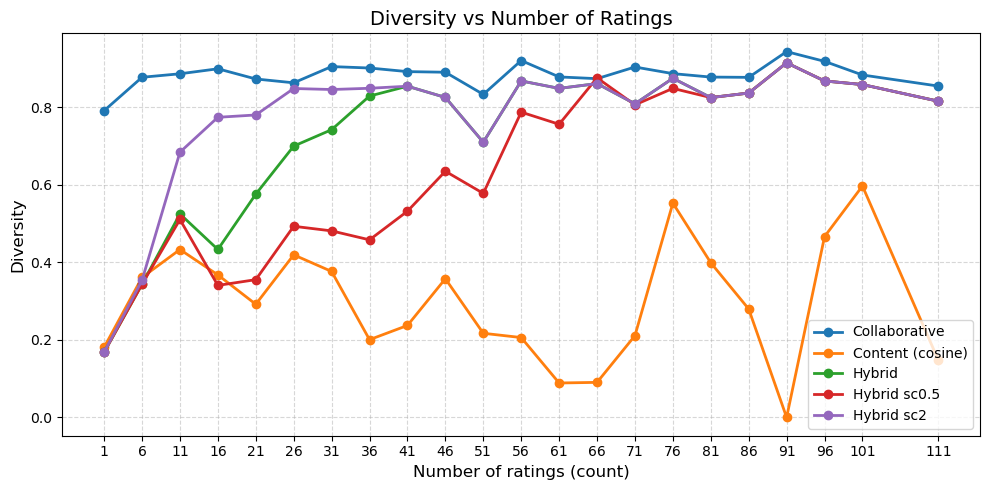

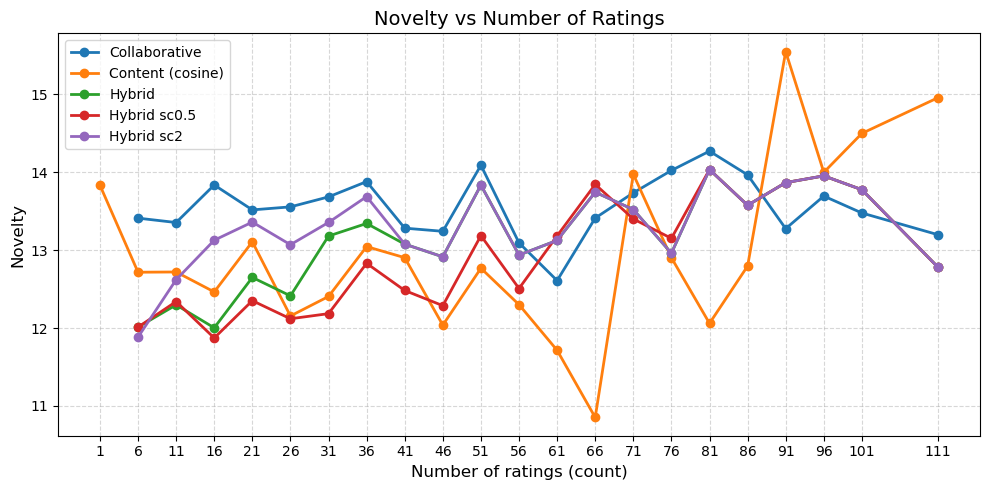

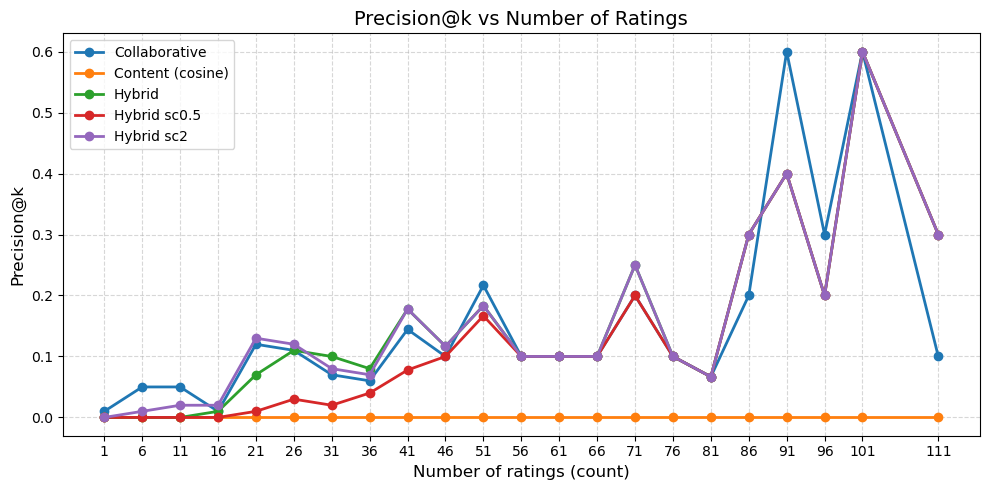

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

output_dir = '/home/jovyan/work/output/plots'
os.makedirs(output_dir, exist_ok=True)

# --- Plot diversity evolution per rating count ---
def plot_metric(results, metric='diversity', filter=None, name=""):
    # Reshape results dict into a DataFrame
    rows = []
    for count, systems in results.items():
        for system_name, metrics in systems.items():
            if not filter or system_name in filter:
                rows.append({
                'count':       count,
                'system':      system_name,
                metric:        metrics[metric]
            })

    df = pd.DataFrame(rows).sort_values('count')

    fig, ax = plt.subplots(figsize=(10, 5))

    for system_name, group in df.groupby('system'):
        ax.plot(
            group['count'],
            group[metric],
            marker='o',
            label=system_name,
            linewidth=2
        )

    ax.set_xlabel('Number of ratings (count)', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f'{metric.capitalize()} vs Number of Ratings', fontsize=14)
    ax.set_xticks(df['count'].unique())
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{metric}_evolution_4{name}.svg', format='svg', bbox_inches='tight')
    plt.show()

filter = ['Collaborative', 'Hybrid', 'Hybrid sc0.5', 'Hybrid sc2', 'Content (cosine)']

plot_metric(results, metric='diversity', filter=filter)
plot_metric(results, metric='novelty',filter=filter)
plot_metric(results, metric='precision@k',filter=filter)

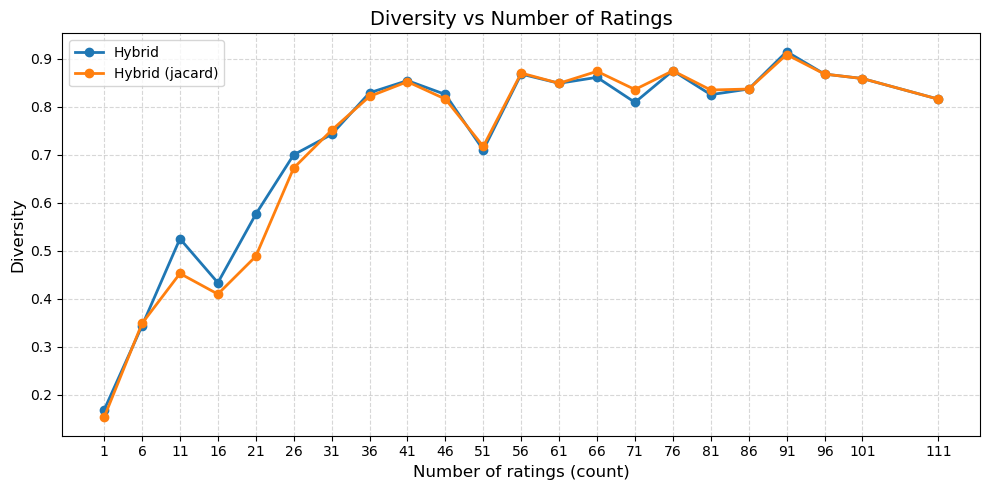

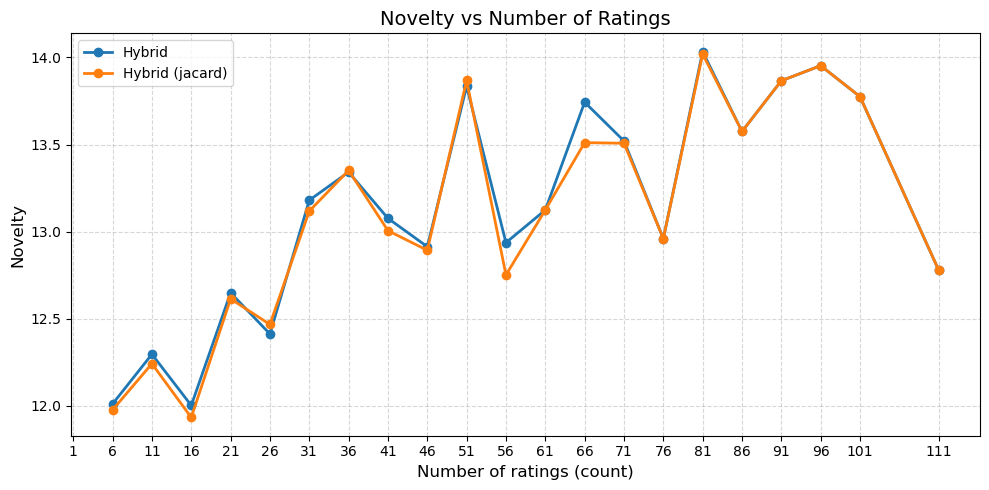

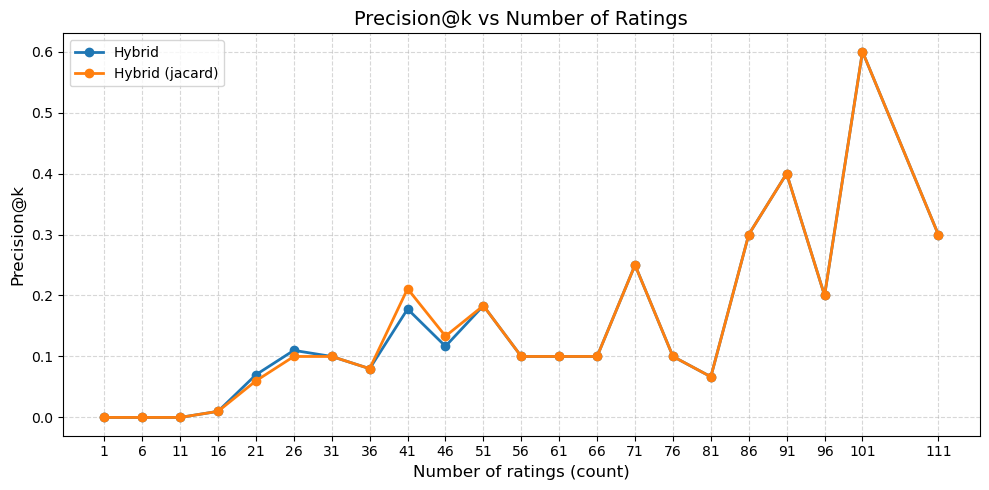

In [11]:
filter = ['Hybrid', 'Hybrid (jacard)']
plot_metric(results, metric='diversity',filter=filter, name="_H_simVjac")
plot_metric(results, metric='novelty',filter=filter, name="_H_simVjac")
plot_metric(results, metric='precision@k',filter=filter, name="_H_simVjac")

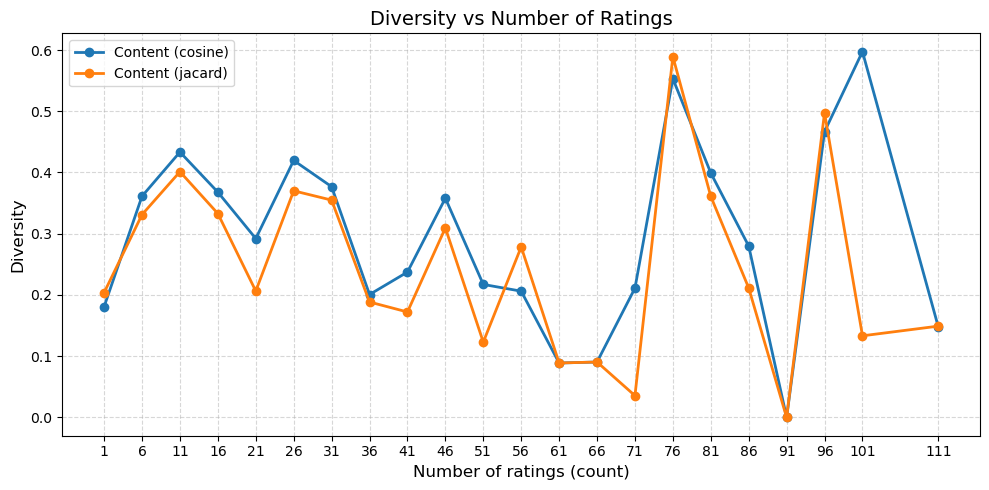

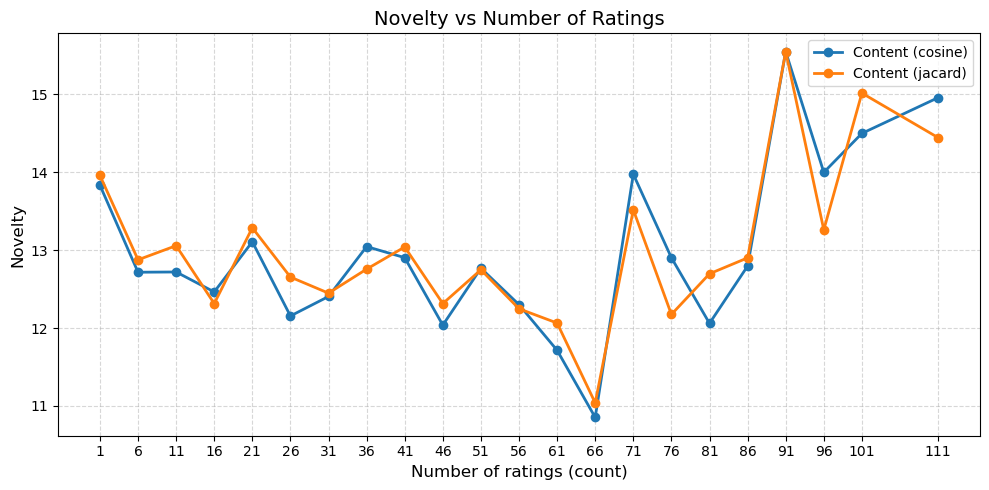

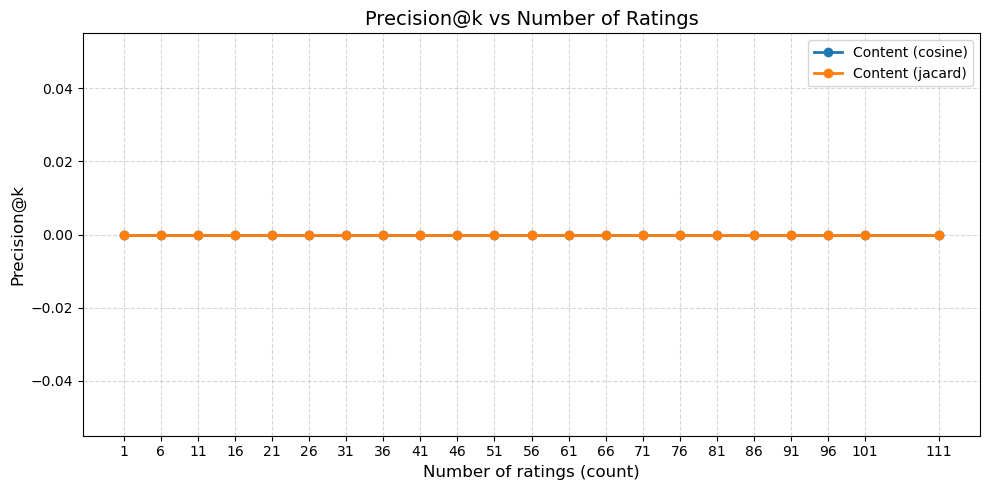

In [20]:
filter = ['Content (cosine)', 'Content (jacard)']
plot_metric(results, metric='diversity',filter=filter, name="_C_cosVjac")
plot_metric(results, metric='novelty',filter=filter, name="_C_cosVjac")
plot_metric(results, metric='precision@k',filter=filter, name="_C_cosVjac")

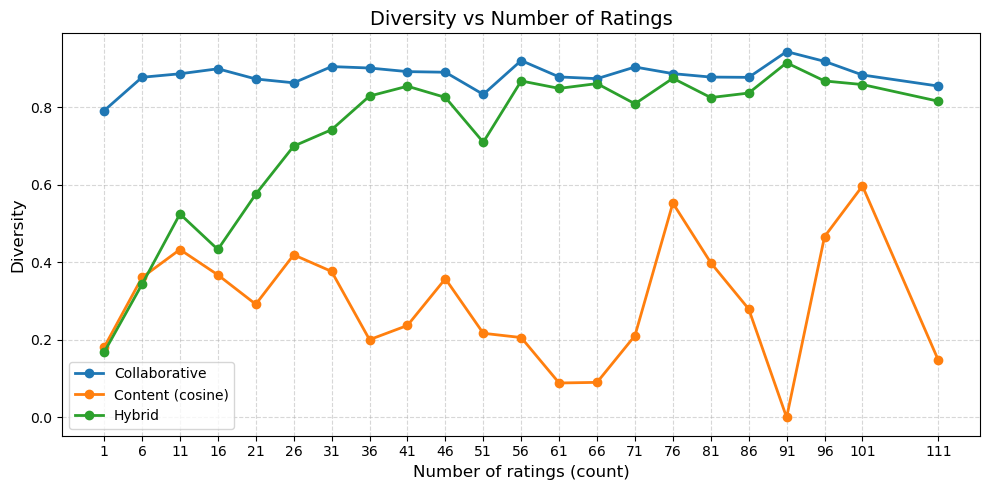

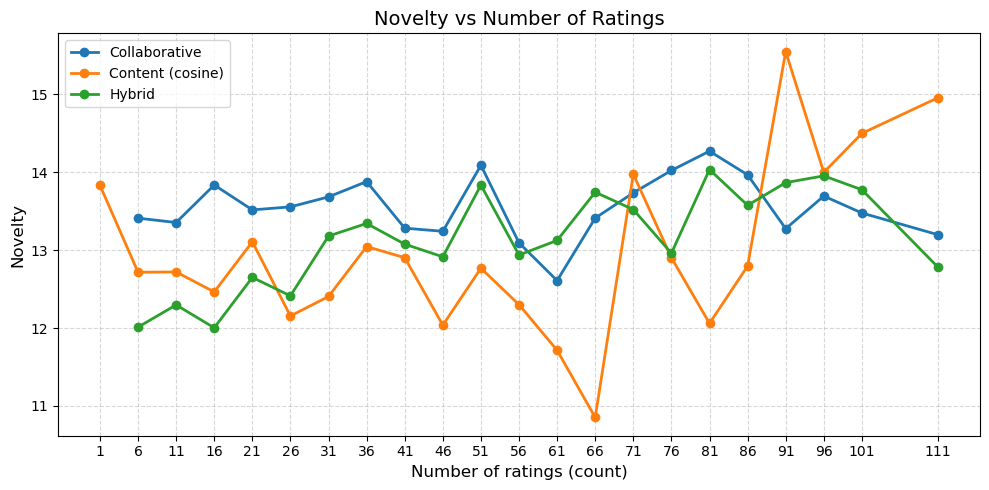

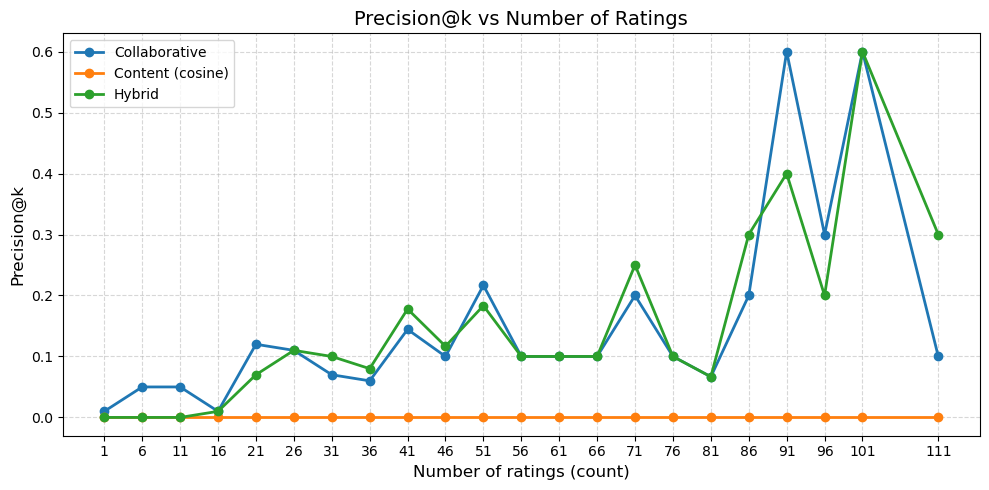

In [22]:
filter = ['Hybrid','Collaborative', 'Content (cosine)']

plot_metric(results, metric='diversity',filter=filter, name="_C_cosVjac")
plot_metric(results, metric='novelty',filter=filter, name="_C_cosVjac")
plot_metric(results, metric='precision@k',filter=filter, name="_C_cosVjac")

In [9]:
import json

# results = {
#     str(count): {
#         name: {
#             metric: round(float(np.mean(values)), 4)
#             for metric, values in metrics.items()
#         }
#         for name, metrics in systems.items()
#     }
#     for count, systems in results.items()
# }

with open('/home/jovyan/work/output/results_agg.json', 'w') as f:
    json.dump(results, f, indent=2)